# Описание бизнес-задачи

## Идея проекта

Есть множество студий, бизнес проектов в игровой сфере, которые стремятся создать успешный проект. Для этого им необходимо понимать интересы аудитории, их финансовые возможности, создания интереса механик и тд.

Однако эта информация является разрозренной, **находится в разных местах и нигде не консолидирована.**

Данное работа направлена на решение данной проблематики, а именно исследование рынка инди-игр, чтобы предоставить таким компаниям отчет, который можно будет использовать для верхнеуровневой оценки рынка, пользовательских интересов и ценообразования конкурентов.

В рамках данной работы будут рассматриваться метркии популярности, рейтинга и тд и их связь с менее очевидными признаками, чтобы предоставить бизнес-заказчикам полную картину текущего рынка.

В конце работы будут даны выводы и рекомендации для инди-разработчиков.

# Обзор датасета

## Импорт данных

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/df_final.csv')
df.columns

Index(['game_name', 'game_description_snippet', 'game_price',
       'found_game_price', 'all_language_reviews_type',
       'all_language_reviews_count', 'has_russian_reviews',
       'all_russian_reviews_type', 'all_russian_reviews_count',
       'first_release_date', 'genres', 'total_rating', 'total_rating_count',
       'popularity_igdb', 'reviews_score', 'russian_reviews_score',
       'has_external_platform'],
      dtype='str')

Удалим некоторые столбцы, которые были нужны для очистки, слияния датасетов, парсинга и апи, так как на этапе EDA, они не несут никакой пользы. Также, удалим столбцы с популярностью на Steam и Twitch, так как, к сожалению, процент пропусков в этих столбцах не даст также никаких возможностей для их анализа. Удалим support_ru_region, так как там unique() - 1

In [58]:

df

,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,reviews_score,russian_reviews_score,has_external_platform
0,Hollow,« Меня не интересовал этот корабль... комплекс...,419.0,1.0,В основном отрицательные,231.0,0.0,Отзывы отсутствуют,0.0,2017-11-16,"Shooter, Puzzle, Adventure",50.000000,3.0,2.053926e-05,3.0,0.0,True
1,Bloody Glimpse,Bloody Glimpse will take you on a immersive jo...,42.0,1.0,Смешанные,227.0,0.0,Отзывы отсутствуют,0.0,2017-09-29,Simulator,40.000000,1.0,7.839350e-07,5.0,0.0,True
2,"John, The Zombie","Welcome to Johnwood, a weird and mysterious pl...",259.0,1.0,Смешанные,179.0,0.0,Отзывы отсутствуют,0.0,2017-11-22,Simulator,50.000000,0.0,1.553492e-06,5.0,0.0,True
3,After Death,After Death is a platform / exploration game i...,299.0,1.0,Очень положительные,146.0,0.0,Отзывы отсутствуют,0.0,2017-10-05,Adventure,70.000000,3.0,1.168714e-05,8.0,0.0,False
4,Shadows of Kurgansk,"Shadows of Kurgansk — игра, в которой вам пред...",200.0,1.0,Смешанные,197.0,0.0,Отзывы отсутствуют,0.0,2016-12-15,"Role-playing (RPG), Simulator, Adventure",50.000000,0.0,0.000000e+00,5.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8715,Choice of the Deathless,"Battle demons and undead attorneys, and win so...",200.0,1.0,Очень положительные,307.0,0.0,Отзывы отсутствуют,0.0,2014-07-05,Role-playing (RPG),77.500000,5.0,5.473167e-06,8.0,0.0,True
8716,Wormster Dash,Prepare yourself for a one-of-its-kind platfor...,61.0,1.0,Положительные,37.0,0.0,Отзывы отсутствуют,0.0,2018-03-29,Adventure,44.680853,2.0,3.121362e-06,6.0,0.0,True
8717,The Thing: Space X,At your disposal are a dozen of the best comba...,42.0,1.0,Смешанные,52.0,0.0,Отзывы отсутствуют,0.0,2017-09-20,Adventure,50.000000,1.0,3.905297e-06,5.0,0.0,False
8718,Dragon Bros,Роботы заполонили собой все и уничтожают место...,199.0,1.0,Положительные,20.0,0.0,Отзывы отсутствуют,0.0,2016-09-16,UNDEFINED,73.500000,1.0,1.553492e-06,6.0,0.0,True


In [59]:
df.columns

Index(['game_name', 'game_description_snippet', 'game_price',
       'found_game_price', 'all_language_reviews_type',
       'all_language_reviews_count', 'has_russian_reviews',
       'all_russian_reviews_type', 'all_russian_reviews_count',
       'first_release_date', 'genres', 'total_rating', 'total_rating_count',
       'popularity_igdb', 'reviews_score', 'russian_reviews_score',
       'has_external_platform'],
      dtype='str')

## Распределение числовых переменных

### Распределение количества игр по годам релиза

Посмотрим на распределение игр по годам релиза

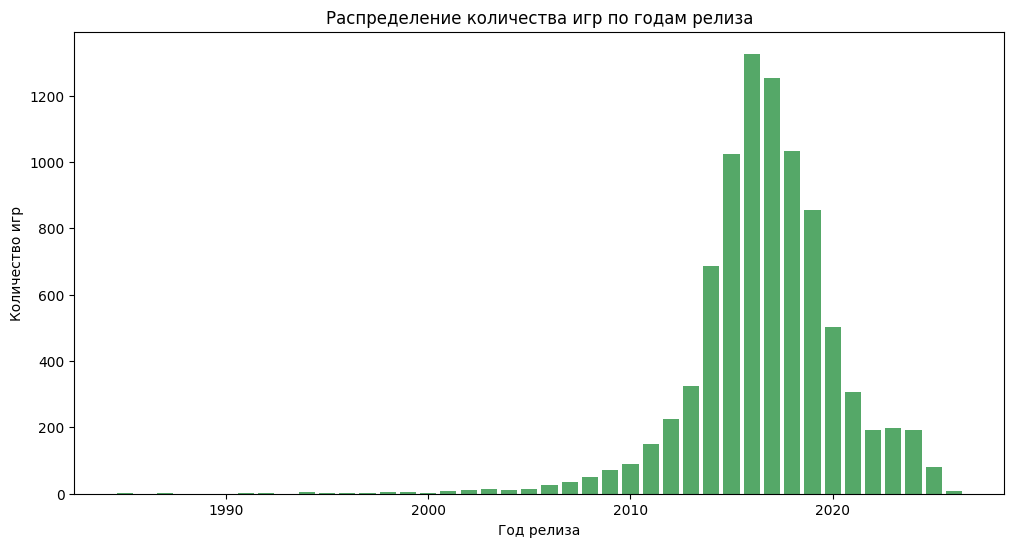

In [60]:
df['year_release'] = pd.to_datetime(df['first_release_date']).dt.year
year_release = df['year_release'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(year_release.index, year_release.values, color='#55A868')
plt.title('Распределение количества игр по годам релиза')
plt.xlabel('Год релиза')
plt.ylabel('Количество игр')

plt.show()

Основная масса игр вышла в период с примерно 2014 по 2020 год, пик был в 2016-17 годах, далее трудно проинтерпретировать, так как причин может быть множество. Расти количество релизов игр начало примерно после 2000 года, но до 2010, игр крайне мало

### Цена

#### Распределение и boxplot цены

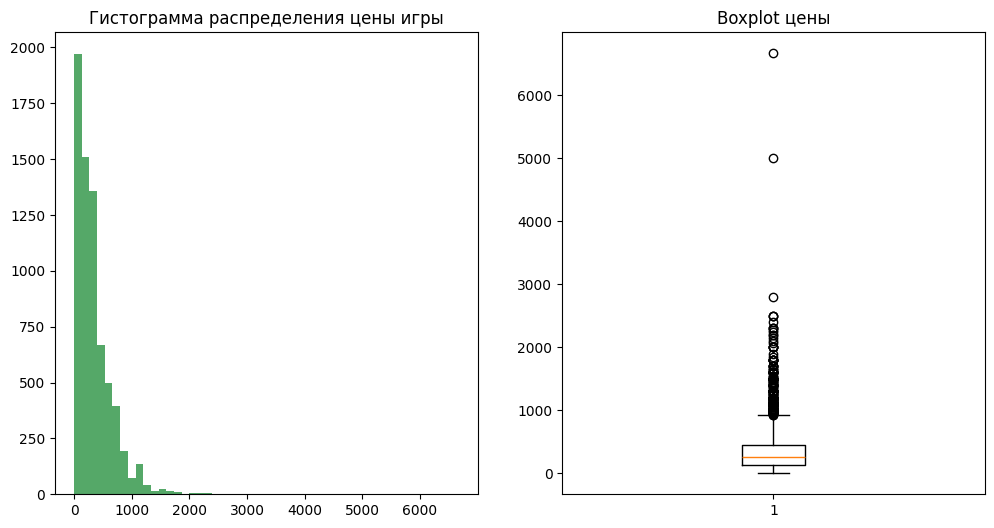

In [61]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(df[df['found_game_price'] == 1]['game_price'], color='#55A868', bins = 50)
plt.title('Гистограмма распределения цены игры')

plt.subplot(1,2,2)
plt.boxplot(df[df['found_game_price'] == 1]['game_price'])
plt.title('Boxplot цены')

plt.show()

Можно заметить, что цена большая часть игры находится в диапазне до 500 рублей, гораздо реже больше, и уже единичные игры, которые стоят более 2000.
По боксплоту видим скопление верхних выбросов в промежутке от 1000 - 3000, и 2 единичных выборса , где стоимость превышает 5000 и 6000.

### Отзывы на всех языках

#### Распределение количества отзывов на всех языках.

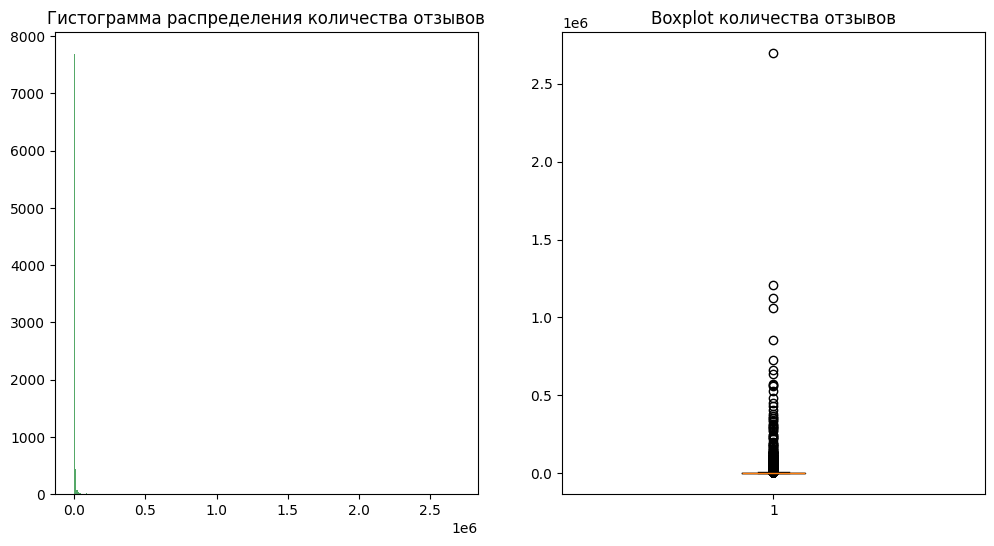

In [62]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(df['all_language_reviews_count'], color='#55A868', bins = 500)
plt.title('Гистограмма распределения количества отзывов')


plt.subplot(1,2,2)
plt.boxplot(df['all_language_reviews_count'].dropna())
plt.title('Boxplot количества отзывов')

plt.show()

Можно заметить, что у большей части игр число отзывов минимально, и близко к 0 (можно вспомнить, что 99% стартапов умирают в первые 3 года), при этом есть единорооги, у которых огромное количество отзывовв

### Русскоязычные отзывы

#### Наличие русских отзывов

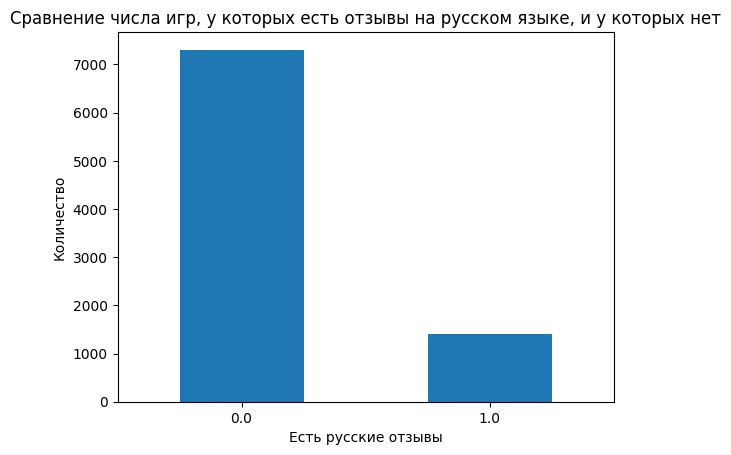

In [63]:
df['has_russian_reviews'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.title('Сравнение числа игр, у которых есть отзывы на русском языке, и у которых нет')
plt.xlabel('Есть русские отзывы')
plt.ylabel('Количество')
plt.show()

Можно заметить, что у более 70% из датафрейма нет русских отзывов, они есть лишь у малого числа игр.

Посмотрим, как выглядит распределение количества русскоязычных отзывов у игр, у которых они есть


#### Распределение количества русскоязычных отзывов

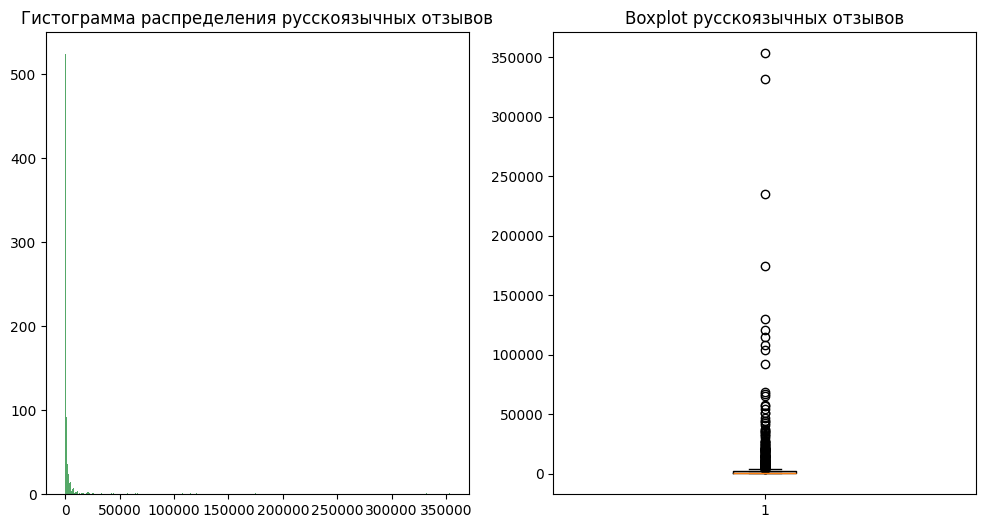

In [64]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(df[df['has_russian_reviews'] == 1]['all_russian_reviews_count'], color='#55A868', bins = 1000)
plt.title('Гистограмма распределения русскоязычных отзывов')

plt.subplot(1,2,2)
plt.boxplot(df[df['has_russian_reviews'] == 1]['all_russian_reviews_count'])
plt.title('Boxplot русскоязычных отзывов')

plt.show()

Можно заметить, что у большинства игр, у которых есть русские отзыввы их число около нулеове, лишь у немногих игр, у которых оно больше, и которые являются выбросами имеют число отзывов в несколько тысяч и более

### Рейтинг

Перейдем к важному, таргету. Для нас, таргетом, целевой переменной является - total_rating. Сделаем некий первичный univariate анализ.

#### Распределение и boxplot рейтинга

In [65]:
target = 'total_rating'
target_n = 'total_rating_count'

df['total_rating'].describe()

count    8720.000000
mean       66.359132
std        12.583383
min         0.000000
25%        60.000000
50%        70.000000
75%        75.875562
max       100.000000
Name: total_rating, dtype: float64

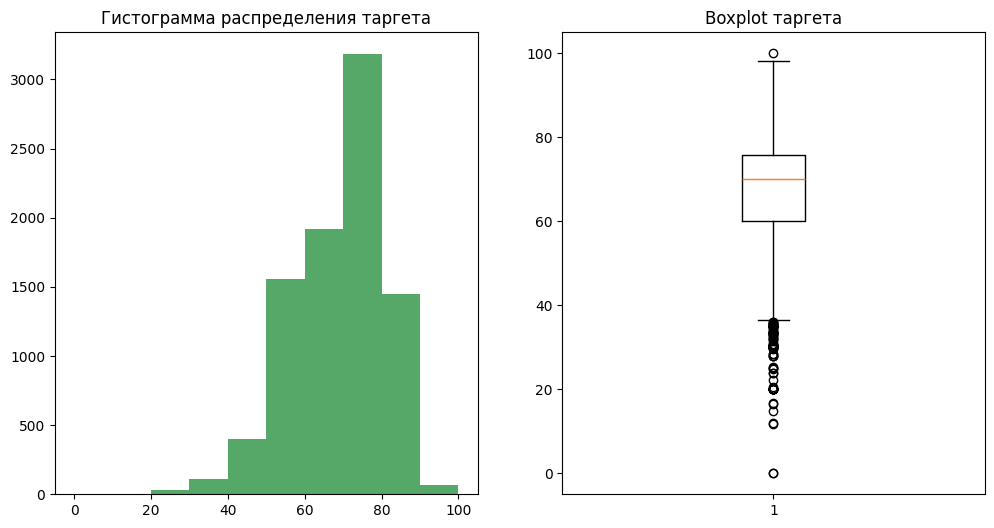

In [66]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(df['total_rating'], color='#55A868')
plt.title('Гистограмма распределения таргета')

plt.subplot(1,2,2)
plt.boxplot(df['total_rating'])
plt.title('Boxplot таргета')

plt.show()

Что заметно, по гистограмме видно, что бОльшая масса наблюдений находится в диапазоне 60-80.
По боксплоту замечаем в основном нижние выбросы, и единичные высокие выбросы, аномалий нет. Можно сказать, что в основном у игр средне-высокие оценки

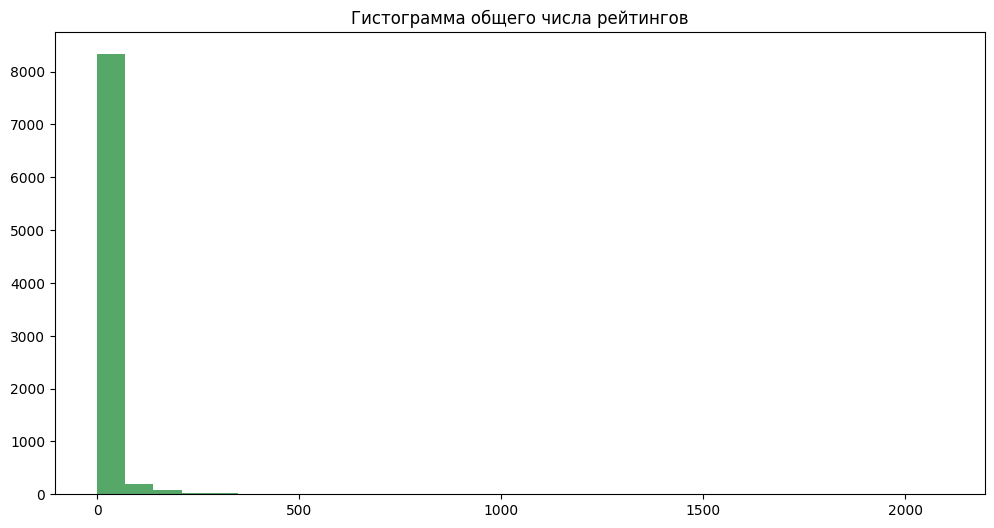

In [67]:
plt.figure(figsize=(12, 6))
plt.hist(df['total_rating_count'], color='#55A868', bins=30)
plt.title('Гистограмма общего числа рейтингов')

plt.show()

По данной гистограмме замечаем, что абсолютное большинство игр получает небольшое число оценок, и только малая часть проектов получает больше

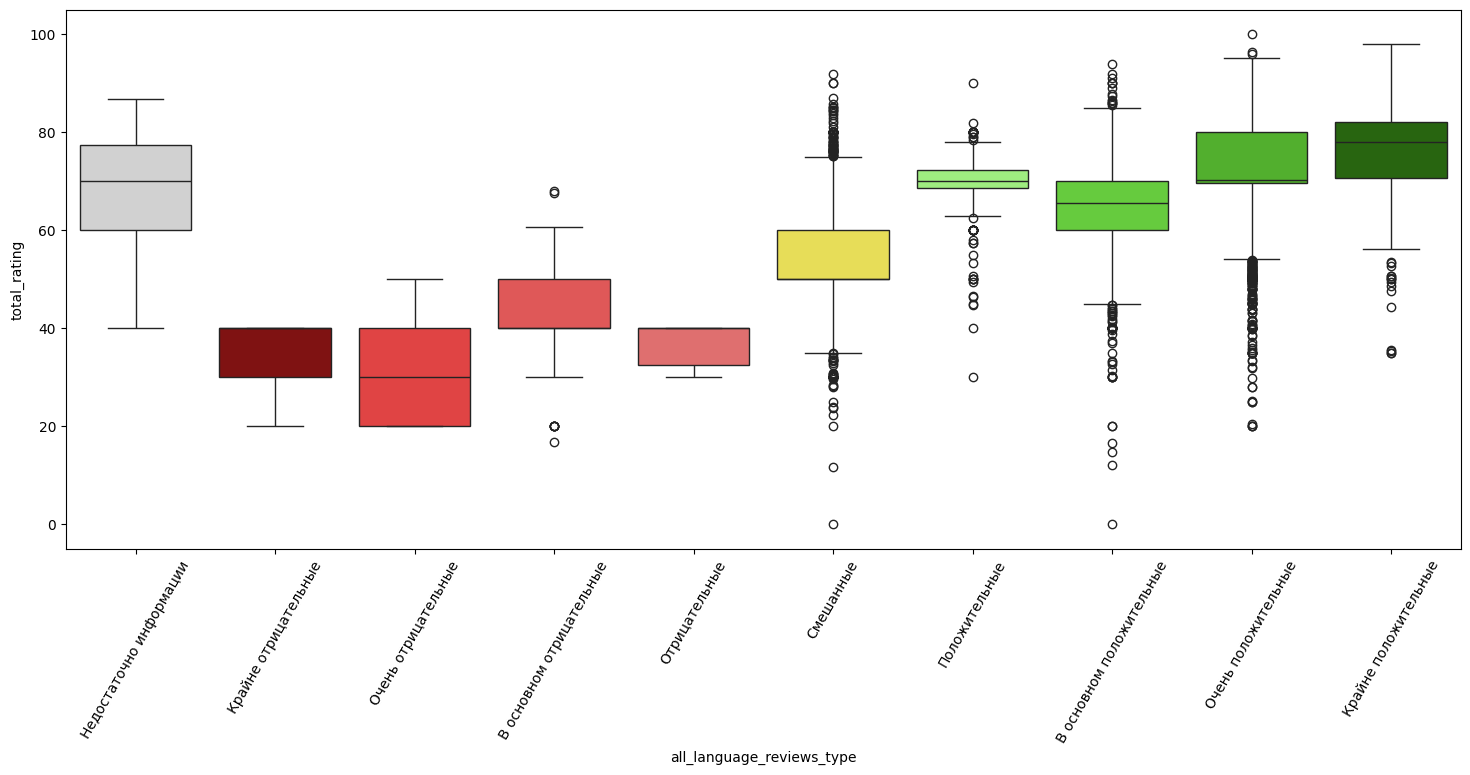

In [68]:
reviews_order = ['Недостаточно информации', 'Крайне отрицательные', 'Очень отрицательные', 'В основном отрицательные', 'Отрицательные', 'Смешанные', 'Положительные', 'В основном положительные', 'Очень положительные', 'Крайне положительные']

reviews_palette = {
    'Недостаточно информации': '#d1d1d1',
    'Крайне отрицательные': '#910000',
    'Очень отрицательные': '#fa2a2a',
    'В основном отрицательные': '#f54242',
    'Отрицательные': '#f25c5c',
    'Смешанные': '#fff240',
    'Положительные': '#97ff6e',
    'В основном положительные': '#5ce327',
    'Очень положительные': '#48c418',
    'Крайне положительные': '#227302'
}


plt.figure(figsize=(18, 7))

sns.boxplot(data=df, x='all_language_reviews_type', y='total_rating', hue='all_language_reviews_type', order=reviews_order, palette=reviews_palette)
plt.xticks(rotation=60)

plt.show()

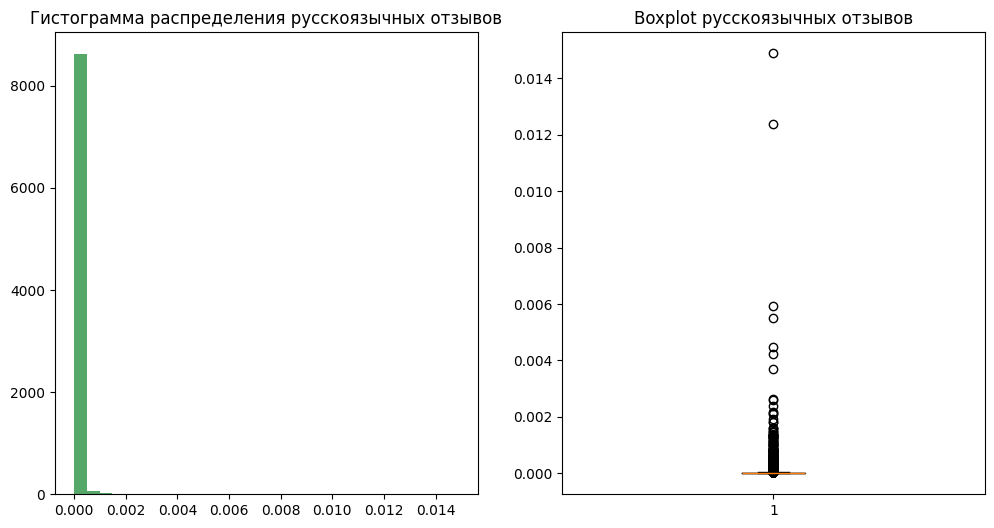

In [69]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(df['popularity_igdb'], color='#55A868', bins = 30)
plt.title('Гистограмма распределения русскоязычных отзывов')

plt.subplot(1,2,2)
plt.boxplot(df['popularity_igdb'])
plt.title('Boxplot русскоязычных отзывов')

plt.show()

## Распределение категориальных и бинарных переменных

### Распределение типов отзывов на всех языках

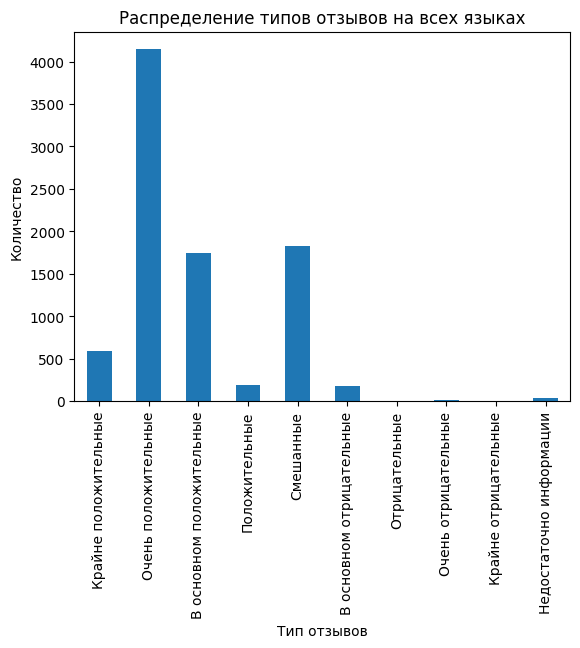

In [70]:
order = [
    'Крайне положительные',
    'Очень положительные',
    'В основном положительные',
    'Положительные',
    'Смешанные',
    'В основном отрицательные',
    'Отрицательные',
    'Очень отрицательные',
    'Крайне отрицательные',
    'Недостаточно информации'
]

df['all_language_reviews_type'].value_counts().reindex(order).plot(kind='bar')
plt.title('Распределение типов отзывов на всех языках')
plt.xlabel('Тип отзывов')
plt.ylabel('Количество')
plt.show()

Заметим, что большинство игр с положительными пользовательскими оценками. Большая часть игр попадает в категорию «Очень положительные», далее идут категории «В основном положительные» и «Смешанные».
Отрицательных отзывов меньшинство

### Распределение типов русскоязычных отзывов

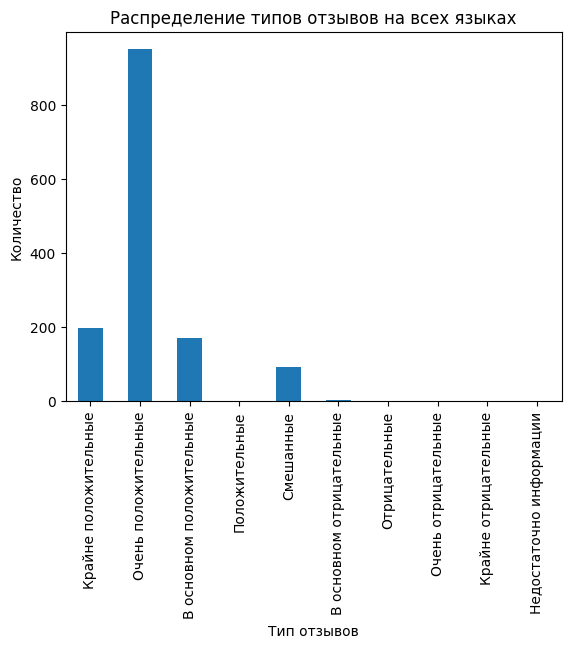

In [71]:
order = [
    'Крайне положительные',
    'Очень положительные',
    'В основном положительные',
    'Положительные',
    'Смешанные',
    'В основном отрицательные',
    'Отрицательные',
    'Очень отрицательные',
    'Крайне отрицательные',
    'Недостаточно информации'
]


df['all_russian_reviews_type'].value_counts().reindex(order).plot(kind='bar')
plt.title('Распределение типов отзывов на всех языках')
plt.xlabel('Тип отзывов')
plt.ylabel('Количество')
plt.show()

Заметим, что практически все игры с положительными пользовательскими оценками. Большая часть игр попадает в категорию «Очень положительные», далее идут категории «В основном положительные» и «Смешанные» и «Смешанные».
Отрицательных отзывов практически нет

Можно предположить, что русские пользователи не играют в игры, у которых отрицательные отзывы по всем языкам. Проверим это

#### Зависимость русских отзывов от типа всех отзывов

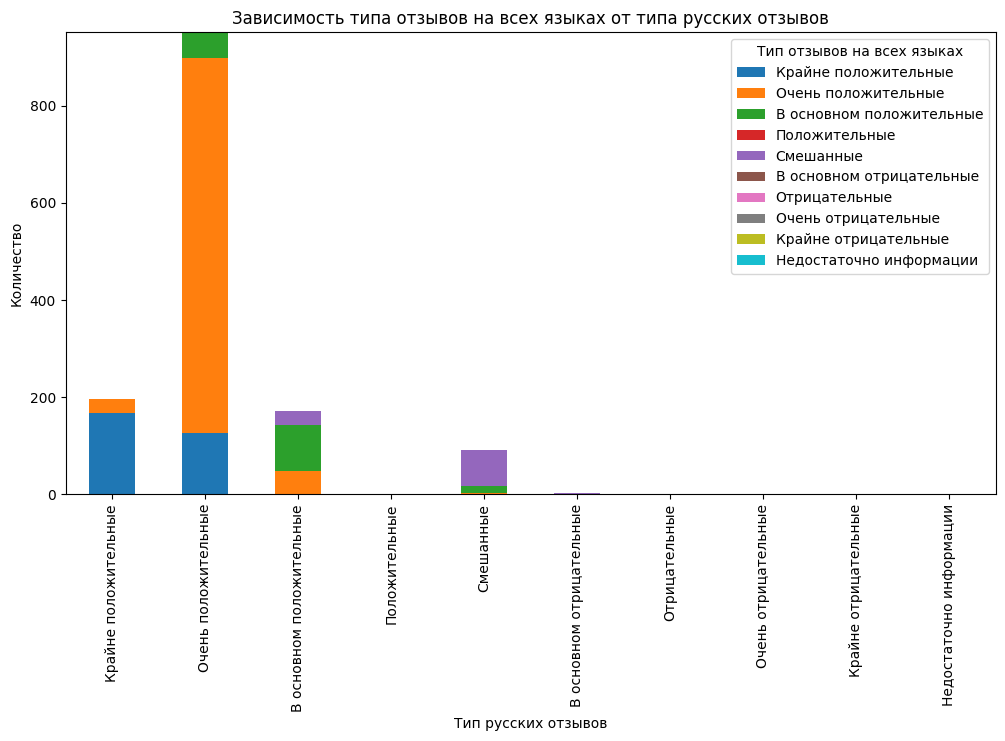

In [72]:
order = [
    'Крайне положительные',
    'Очень положительные',
    'В основном положительные',
    'Положительные',
    'Смешанные',
    'В основном отрицательные',
    'Отрицательные',
    'Очень отрицательные',
    'Крайне отрицательные',
    'Недостаточно информации'
]

ct = pd.crosstab(df['all_russian_reviews_type'], df['all_language_reviews_type'])
ct = ct.reindex(index=order, columns=order, fill_value=0)

ct.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Зависимость типа отзывов на всех языках от типа русских отзывов')
plt.xlabel('Тип русских отзывов')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.legend(title='Тип отзывов на всех языках')
plt.show()

Можно заметить, что да, наша гипотеза оказалась верной и русские отзывы, есть только на играх, где отзывы на всех языках неотрицательные (т.е положительные или смешанные)

## Взаимосвязь между переменными

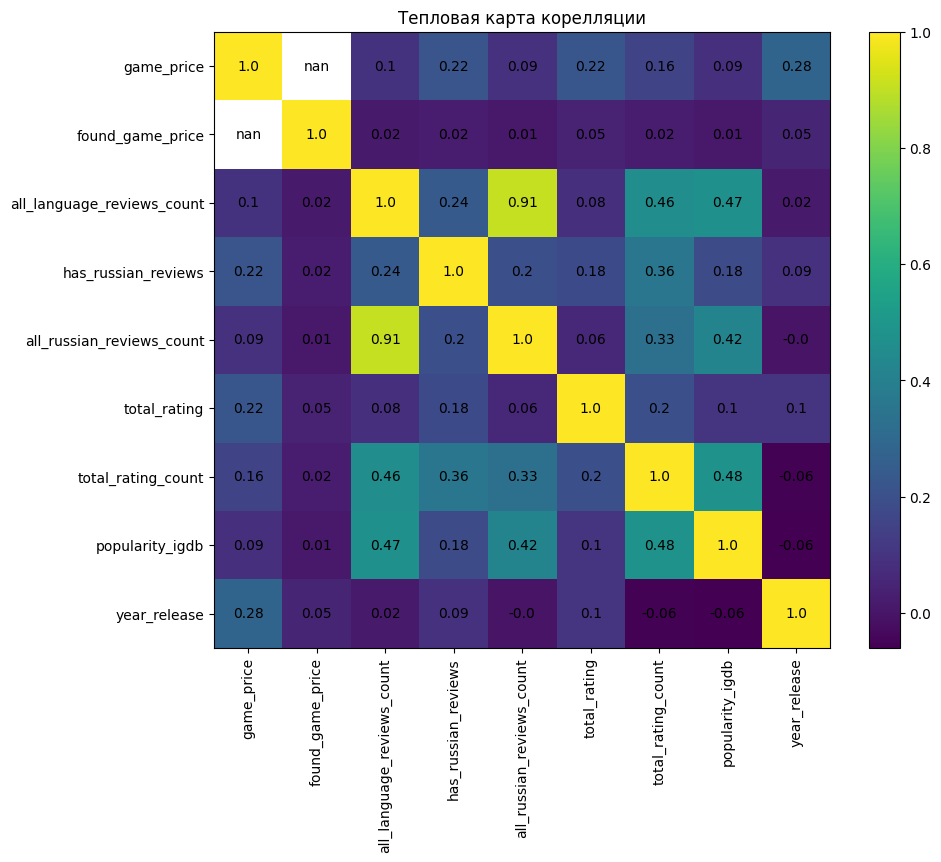

In [73]:
cols = [
    'game_price',
    'found_game_price',
    'all_language_reviews_count',
    'has_russian_reviews',
    'all_russian_reviews_count',
    'total_rating',
    'total_rating_count',
    'popularity_igdb',
    'year_release'
]

corr = df[cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center')

plt.title('Тепловая карта корелляции')
plt.show()

Можем заметить, что есть высокая корелляция между отзывами на всех языках и отзывами на русском - это вполне логично, так как, если игра стала популярная по миру, то высока вероятность, что она стала в России.

Можно заметить, что в целом есть слабая или средняя корелляция между количественными оценками, что в целом являет логичным.

# Анализ влияния жанров игры

Для начала первично взглянем на значения в этом признаке

In [74]:
df['genres'].str.split(',').explode().str.strip().value_counts()

genres
Adventure                    4612
Strategy                     2253
Role-playing (RPG)           2176
Simulator                    2144
Puzzle                       1749
Platform                     1131
Shooter                      1116
Arcade                        976
UNDEFINED                     538
Point-and-click               431
Sport                         335
Turn-based strategy (TBS)     332
Visual Novel                  328
Racing                        323
Fighting                      259
Real Time Strategy (RTS)      228
Tactical                      214
Card & Board Game             187
Music                         183
Quiz/Trivia                    33
Pinball                         9
MOBA                            4
Name: count, dtype: int64

В первую очередь, уберем жанр Indie, т.к. у нас подразумевается что и так все игры - инди.

Перед этим посмотрим, если ли пропуски в данном столбце.

In [75]:
df[df['genres'].isna()]

,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,reviews_score,russian_reviews_score,has_external_platform,year_release


Пропуски есть, но игр тут немного и, как минимум, для части их них можно вручную дописать жанр, даже учитывая описание или название. Но пока добавим для них уникальный жанр - UNDEFINED

In [76]:
df['genres'] = df['genres'].fillna('UNDEFINED')

In [77]:
df['genres'] = df['genres'].apply(lambda x: ', '.join(genre.strip() for genre in x.split(',') if genre.strip() != 'Indie')) # сначала разделяем строку на элементы по ",", применяем strip + проверяем, что значение не Indie и вновь собираем строку через ', '.join

In [78]:
df['genres'].str.split(',').explode().str.strip().value_counts()

genres
Adventure                    4612
Strategy                     2253
Role-playing (RPG)           2176
Simulator                    2144
Puzzle                       1749
Platform                     1131
Shooter                      1116
Arcade                        976
UNDEFINED                     538
Point-and-click               431
Sport                         335
Turn-based strategy (TBS)     332
Visual Novel                  328
Racing                        323
Fighting                      259
Real Time Strategy (RTS)      228
Tactical                      214
Card & Board Game             187
Music                         183
Quiz/Trivia                    33
Pinball                         9
MOBA                            4
Name: count, dtype: int64

Можно заметить, что у нас появились по всей видимости игры без жанра - там был указан только Indie. К ним ничего не остается, кроме как установить ранее введеный "жанр" - UNDEFINED

In [79]:
df.loc[df['genres'] == '', 'genres'] = 'UNDEFINED'

In [80]:
df['genres'].str.split(',').explode().str.strip().value_counts()

genres
Adventure                    4612
Strategy                     2253
Role-playing (RPG)           2176
Simulator                    2144
Puzzle                       1749
Platform                     1131
Shooter                      1116
Arcade                        976
UNDEFINED                     538
Point-and-click               431
Sport                         335
Turn-based strategy (TBS)     332
Visual Novel                  328
Racing                        323
Fighting                      259
Real Time Strategy (RTS)      228
Tactical                      214
Card & Board Game             187
Music                         183
Quiz/Trivia                    33
Pinball                         9
MOBA                            4
Name: count, dtype: int64

In [81]:
df['genres'].value_counts().head(20)

genres
Adventure                                   752
UNDEFINED                                   538
Role-playing (RPG), Adventure               483
Puzzle, Adventure                           308
Simulator, Strategy                         296
Simulator                                   263
Strategy                                    233
Shooter                                     230
Platform, Puzzle, Adventure                 197
Platform, Adventure                         187
Simulator, Adventure                        185
Point-and-click, Puzzle, Adventure          184
Role-playing (RPG)                          166
Shooter, Arcade                             132
Puzzle                                      126
Role-playing (RPG), Strategy, Adventure     117
Role-playing (RPG), Simulator, Adventure    113
Point-and-click, Adventure                  105
Shooter, Adventure                           98
Adventure, Visual Novel                      98
Name: count, dtype: int64

У нас довольно много игр, где присутствует жанр Adventure, попробуем посмотреть сколько таких игр. Исключим игры без указанного жанра.

In [82]:
df_games_w_genre = df[df['genres'] != 'UNDEFINED']
print(f'Игр, с жанром Adventure: {df_games_w_genre[df_games_w_genre['genres'].str.contains('Adventure')].shape[0] / df_games_w_genre.shape[0] * 100}%')

Игр, с жанром Adventure: 56.36763627474946%


Почти половина всех игр - с жанром Adventure. Посмотрим альтернативные наблюдения и по другим жанрам, также посчитаем некоторые описательные статистики для каждого жанра.

In [83]:
genres = df['genres'].str.split(',').explode().str.strip().value_counts().reset_index()

Посчитаем долю игр с таким жанром, а также медиану и среднее для рейтинга и обзоров в Steam

In [84]:
genres['share'] = genres['genres'].apply(lambda x: df_games_w_genre['genres'].str.contains(x, regex=False).sum() / df_games_w_genre.shape[0])
genres['total_rating_median'] = genres['genres'].apply(lambda x: df_games_w_genre.loc[df_games_w_genre['genres'].str.contains(x, regex=False), 'total_rating'].median())
genres['total_rating_mean'] = genres['genres'].apply(lambda x: df_games_w_genre.loc[df_games_w_genre['genres'].str.contains(x, regex=False), 'total_rating'].mean())
genres['reviews_count_median'] = genres['genres'].apply(lambda x: df_games_w_genre.loc[df_games_w_genre['genres'].str.contains(x, regex=False), 'all_language_reviews_count'].median())
genres['reviews_count_mean'] = genres['genres'].apply(lambda x: df_games_w_genre.loc[df_games_w_genre['genres'].str.contains(x, regex=False), 'all_language_reviews_count'].mean())
# regex=False, т.к. иначе жанры по типу Role-playing (RPG) в str.contains по умолчанию воспринимаю скобки как часть регулярного выражения

In [85]:
genres[genres['genres'] != 'UNDEFINED']

,genres,count,share,total_rating_median,total_rating_mean,reviews_count_median,reviews_count_mean
0,Adventure,4612,0.563676,70.000000,67.008615,484.0,5823.251951
1,Strategy,2253,0.276338,70.000000,66.138093,502.0,6252.744361
2,Role-playing (RPG),2176,0.265950,70.000000,66.897135,591.5,7366.630515
3,Simulator,2144,0.262039,69.749908,65.339701,694.0,8948.332556
4,Puzzle,1749,0.213762,70.000000,69.307001,484.0,3919.003431
5,Platform,1131,0.138230,70.683974,70.094925,408.0,5718.033599
6,Shooter,1116,0.136397,70.000000,66.361842,535.5,11920.555556
7,Arcade,976,0.119286,70.000000,69.261121,306.0,4542.739754
9,Point-and-click,431,0.052677,70.615200,69.363886,641.0,2712.819026
10,Sport,335,0.040944,70.000000,65.907702,349.0,3707.835821


Посчитаем тоже самое, но уже для всей выборки

In [86]:
pd.Series({'total_rating_median': df_games_w_genre['total_rating'].median(), 'total_rating_mean': df_games_w_genre['total_rating'].mean(), 'reviews_count_median': df_games_w_genre['all_language_reviews_count'].median(),	'reviews_count_mean': df_games_w_genre['all_language_reviews_count'].mean()})

total_rating_median       70.000000
total_rating_mean         66.539605
reviews_count_median     432.000000
reviews_count_mean      5889.985823
dtype: float64

Можно заметить, что, грубо говоря, у всех жанров, кроме особо редких - медиана и среднее рейтинга примерно одинаковое, как и во всей выборке - около 70. При этом, также близкое значение к медианному значению числа ревью также у большинства жанров, но есть один интересный случай - жанр **Turn-based strategy (TBS)**, у которого и рейтинг выше 70 (да, даже 72 - уже выше чем у всех остальных, кроме случаев с несколькими играми), а также медианное число отзывов почти в 3 раза больше, чем у всей выборки, а число отзывов может говорить о популярности.

Похожая ситуация, но с еще большим числом обзоров, но и с более смещенным средним - что конечно может говорить о наличие выброса, у игр жанра **Tactical**. + Для этого случая рейтинги даже чуть ниже чем во всей выборке.

Сначала посмотрим тогда на сами типы отзывов для **TBS** игр.

In [87]:
tbs_games = df[df['genres'].str.contains('Turn-based strategy (TBS)', regex=False)]

In [88]:
tbs_games_review_counts = tbs_games.groupby('all_language_reviews_type').agg(games_count=('game_name', 'nunique'), reviews_count=('all_language_reviews_count', 'sum')).reset_index()

In [89]:
tbs_games_review_counts

,all_language_reviews_type,games_count,reviews_count
0,В основном отрицательные,3,1034.0
1,В основном положительные,77,133281.0
2,Крайне положительные,27,993397.0
3,Очень положительные,166,1126019.0
4,Положительные,2,91.0
5,Смешанные,57,127168.0


у нас есть две категории, с всего 5 играми и сильно меньшим числом обзоров. На графиках ниже они не дадут никакой информации, кроме того что значения у них значительно меньше, так что просто уберем их

In [90]:
tbs_games_review_counts = tbs_games_review_counts[tbs_games_review_counts['games_count'] > 3]

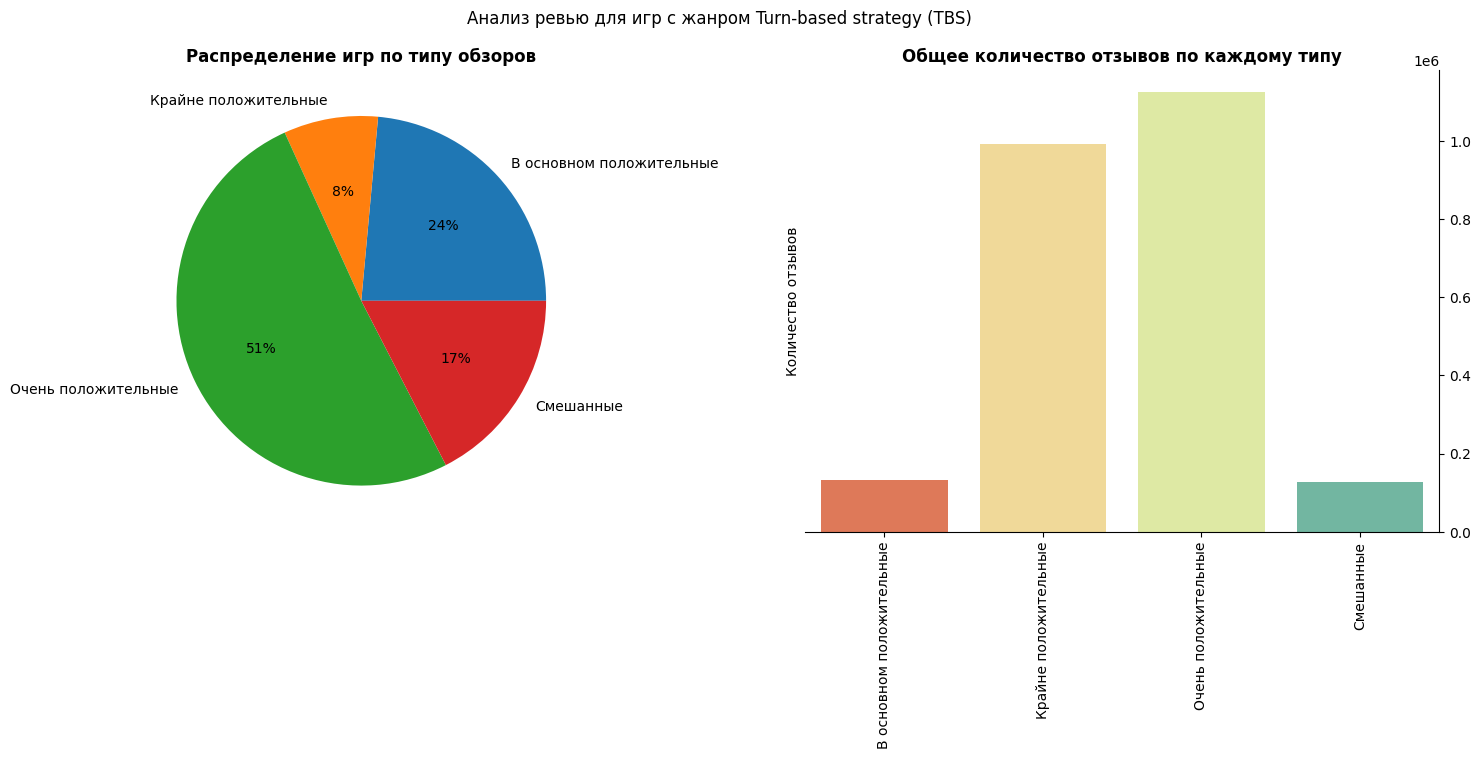

In [91]:
plt.figure(figsize=(18, 6))

plt.suptitle('Анализ ревью для игр с жанром Turn-based strategy (TBS)')

plt.subplot(1,2,1)

plt.title('Распределение игр по типу обзоров', fontweight='bold')
plt.pie(tbs_games_review_counts['games_count'], labels=tbs_games_review_counts['all_language_reviews_type'], autopct='%.0f%%')

plt.subplot(1,2,2)

plt.title('Общее количество отзывов по каждому типу', fontweight='bold')
sns.barplot(tbs_games_review_counts, x='all_language_reviews_type', y='reviews_count', hue='all_language_reviews_type', palette='Spectral')
sns.despine(left=True, top=True, right=False)
plt.gca().yaxis.tick_right() # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.gca.html
plt.xlabel('')
plt.xticks(rotation=90)
plt.ylabel('Количество отзывов')

plt.show()

Можем заметить, что большая часть средней оценки обзоров на эти игры - это довольно положительные отзывы, наихудший из вариантов на графиках - "Смешанные", которых всего 17%.

Теперь тоже самое сделаем для игр жанра **Tactical**

In [92]:
tactical_games = df[df['genres'].str.contains('Tactical', regex=False)]
tactical_games_review_counts = tactical_games.groupby('all_language_reviews_type').agg(games_count=('game_name', 'nunique'), reviews_count=('all_language_reviews_count', 'sum')).reset_index()
tactical_games_review_counts

,all_language_reviews_type,games_count,reviews_count
0,В основном отрицательные,3,967.0
1,В основном положительные,53,616786.0
2,Крайне положительные,11,1117189.0
3,Очень положительные,105,1119049.0
4,Положительные,1,40.0
5,Смешанные,41,205414.0


Аналогично, с той же аргументаций по выбросу части строк об отзывах, выкинем строки для отзывов "В основном отрицательные" и "Положительные"

In [93]:
tactical_games_review_counts = tactical_games_review_counts[tactical_games_review_counts['games_count'] > 3]

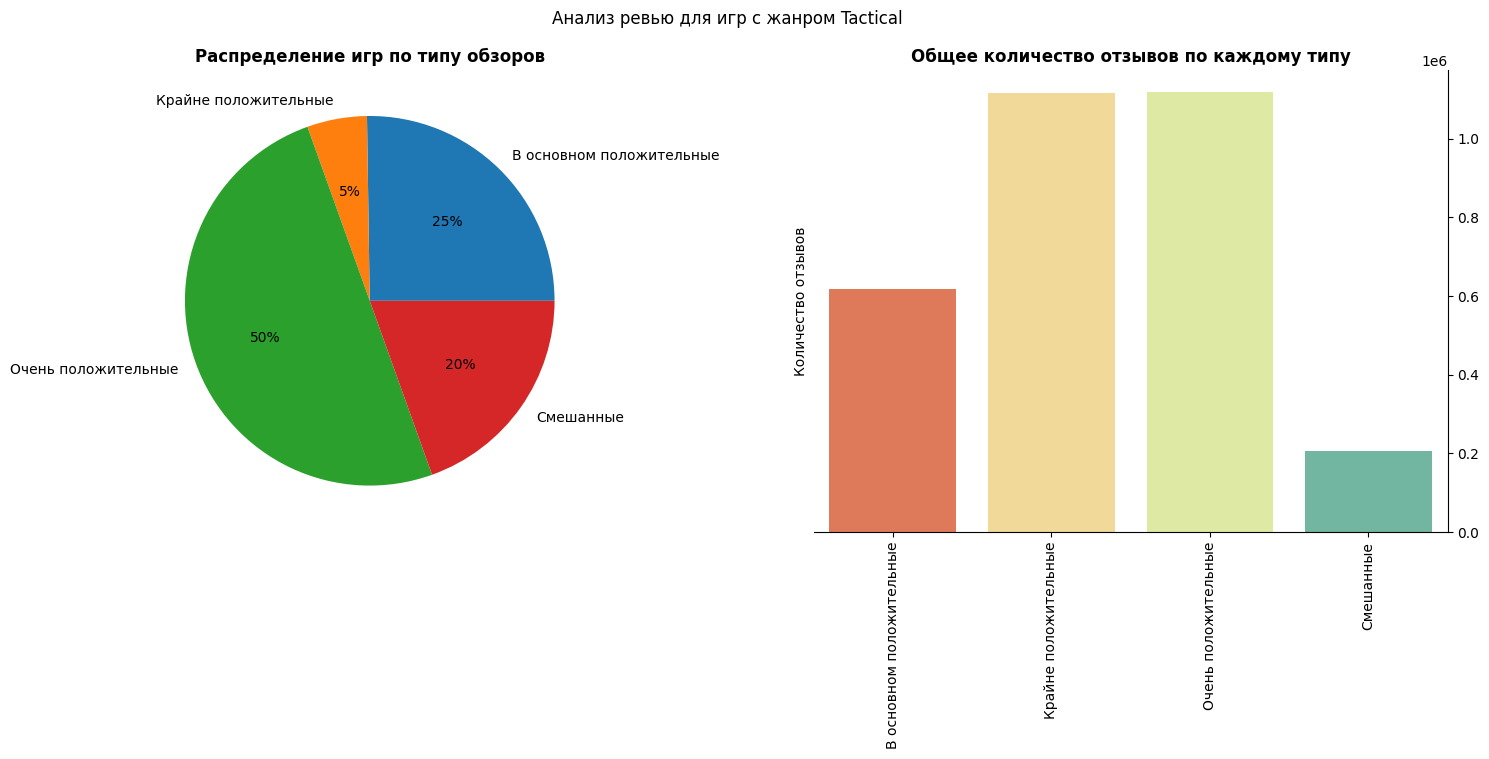

In [94]:
plt.figure(figsize=(18, 6))

plt.suptitle('Анализ ревью для игр с жанром Tactical')

plt.subplot(1,2,1)

plt.title('Распределение игр по типу обзоров', fontweight='bold')
plt.pie(tactical_games_review_counts['games_count'], labels=tactical_games_review_counts['all_language_reviews_type'], autopct='%.0f%%')

plt.subplot(1,2,2)

plt.title('Общее количество отзывов по каждому типу', fontweight='bold')
sns.barplot(tactical_games_review_counts, x='all_language_reviews_type', y='reviews_count', hue='all_language_reviews_type', palette='Spectral')
sns.despine(left=True, top=True, right=False)
plt.gca().yaxis.tick_right() # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.gca.html
plt.xlabel('')
plt.xticks(rotation=90)
plt.ylabel('Количество отзывов')

plt.show()

Ситуация очень схожая, смешанных отзывов тут чуть больше - 20% против 17%, но в остальном - также почти все отзывы положительные.

Далее хорошо было бы проверить, действительно ли игры с жанром **Tactical** и **Turn-based strategy (TBS)** влияют на успех игры, который мы оцениваем, в данном случае - это рейтинг.

#### Начнем с TBS

Для это сформулируем нулевую и альтернативную гипотезы.

H0: распределение рейтинга total_rating у игр с жанром Turn-based strategy (TBS) и у игр без этого жанра не различается.

H1: распределение рейтинга total_rating у игр с жанром Turn-based strategy (TBS) и у игр без этого жанра различается.

Для начала скажем, что две эти выборки (с жанром и без) - независимые, т.к. мы рассматриваем строки(игры) где есть этот жанр и где его вообще нет.

Для данного случая, с двумя независимыми выборками и одним общим числовым признаком мы можем использовать t-критерий Стьюдента, но если дисперсии выборок примерно равны и нет сильных выбросов, иначе - тест Манна-Уитни:

Также для всех проверок ниже - зададим уровень значимости в 5%

**Гомогенность дисперсий**

Для проверки гомогенности дисперсий воспользуемся критерием Левена, где:

H0: Дисперсии примерно равны (гомогенность дисперсий).

H1: Дисперсии не равны.

In [95]:
from scipy.stats import levene

not_tbs_games = df[~df['genres'].str.contains('Turn-based strategy (TBS)', regex=False)]

tbs_var = tbs_games['total_rating'].var()
not_tbs_var = not_tbs_games['total_rating'].var()

print(f'Дисперсия у TBS: {tbs_var}')
print(f'Дисперсия у не TBS: {not_tbs_var}')

_, p_value = levene(tbs_games['total_rating'], not_tbs_games['total_rating'])

print(f'p_value = {p_value}')

Дисперсия у TBS: 116.76655063133569
Дисперсия у не TBS: 159.00616567570776
p_value = 0.003269579941902389


Т.к. p_value < 0.05, значит мы отвергаем нулевую гипотезу, а значит дисперсии не равны.

Также посмотрим нет ли сильных выбросов.

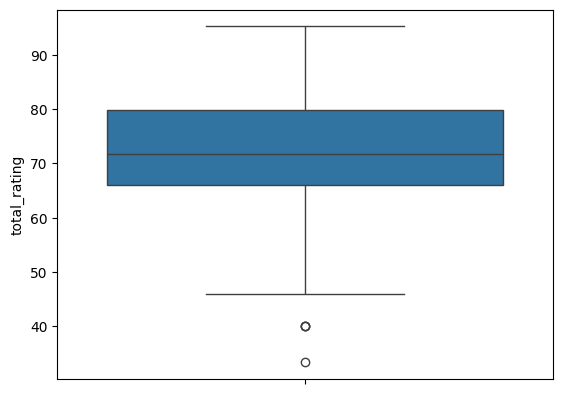

In [96]:
sns.boxplot(tbs_games['total_rating'])
plt.show()

У нас есть несколько выбросов снизу, и в связи с различием дисперсий и наличии выбросов воспользуемся тестом Манна-Уитни

In [97]:
from scipy.stats import mannwhitneyu

_, p_value = mannwhitneyu(tbs_games['total_rating'], not_tbs_games['total_rating'])

print(f"p_value = {p_value}")

p_value = 3.6180097401772635e-12


Т.к. p_value < 0.05, значит мы отвергаем нулевую гипотезу, т.е. распределение рейтинга total_rating у игр с жанром Turn-based strategy (TBS) и у игр без этого жанра различается.

#### Теперь сделаем тоже самое для жанра Tactical

Для это сформулируем нулевую и альтернативную гипотезы.

H0: распределение рейтинга total_rating у игр с жанром Tactical и у игр без этого жанра не различается.

H1: распределение рейтинга total_rating у игр с жанром Tactical и у игр без этого жанра различается.

Такая же аргументация по независимости выборок. И сделаем те же проверки на различие дисперсий и выбросы.

**Гомогенность дисперсий**

Для проверки гомогенности дисперсий также воспользуемся критерием Левена, где:

H0: Дисперсии примерно равны (гомогенность дисперсий).

H1: Дисперсии не равны.

In [98]:
from scipy.stats import levene

not_tactical_games = df[~df['genres'].str.contains('Tactical')]

tactical_var = tactical_games['total_rating'].var()
not_tactical_var = not_tactical_games['total_rating'].var()

print(f'Дисперсия у tactical: {tactical_var}')
print(f'Дисперсия у не tactical: {not_tactical_var}')

_, p_value = levene(tactical_games['total_rating'], not_tactical_games['total_rating'])

print(f'p_value = {p_value}')

Дисперсия у tactical: 143.80358455531285
Дисперсия у не tactical: 158.39329890725256
p_value = 0.037468197741706975


Т.к. p_value < 0.05, значит мы отвергаем нулевую гипотезу, а значит дисперсии не равны.

Также посмотрим нет ли сильных выбросов.

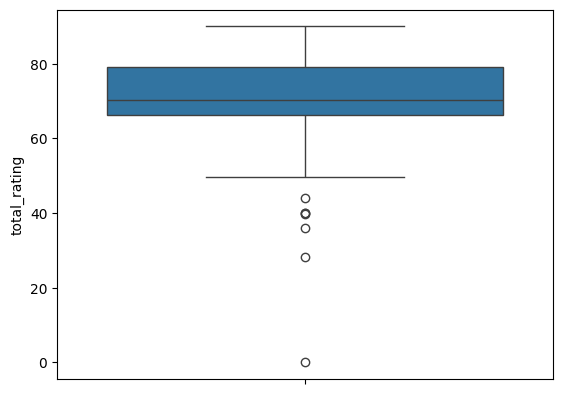

In [99]:
sns.boxplot(tactical_games['total_rating'])
plt.show()

У нас есть несколько выбросов снизу, и в связи с различием дисперсий и наличии выбросов воспользуемся тестом Манна-Уитни

In [100]:
from scipy.stats import mannwhitneyu

_, p_value = mannwhitneyu(tactical_games['total_rating'], not_tactical_games['total_rating'])

print(f"p_value = {p_value}")

p_value = 5.931778161166322e-06


Т.к. p_value < 0.05, значит мы отвергаем нулевую гипотезу, т.е. распределение рейтинга total_rating у игр с жанром Tactical и у игр без этого жанра различается.

**Итого**: После проверки выдвинутых гипотез можем сказать, что жанры Tactical и TBS влияют на рейтинг. Мы не углулблялись, и провери двусторонние гипотезы, ну судя по нашим наблюдениям - у этих жанров все, обычно, неплохо.

Также можем сказать, что игр с жанром Adventure больше всего, мы также это наблюдали при рассмотрении поля с кратким описанием игры. Но во время рассмотрения явных преимуществ от этого рейтинга мы не заметили, кроме того что таких игр довольно много. Так что если задача сделать что-то нетипичное для рынка инди-игр, то лучше сделать что-то отлично от Adventure, к примеру, как раз, пошаговые стратегии, тактические игры, где можно удачно попасть в группу ценителей подобных жанров игр. К тому же, они не такие частовстречаемые, судя по нашей выборке.

## Анализ влияния площадок на рейтинг

Посмотрим на следующий признак, а именно "has_external_platform", попробуем проверить наличие связи между нашим признаком и рейтингом

In [101]:
df['has_external_platform'].value_counts()

has_external_platform
False    5498
True     3222
Name: count, dtype: int64

In [102]:
x = df.groupby('has_external_platform')[['total_rating','total_rating_count','all_language_reviews_count','reviews_score']].agg(['mean','median'])
x


total_rating        total_rating_count         \
                              mean median               mean median   
has_external_platform                                                 
False                    65.272328   70.0          13.407967    2.0   
True                     68.213647   70.0          24.486654    3.0   

                      all_language_reviews_count        reviews_score         
                                            mean median          mean median  
has_external_platform                                                         
False                                2910.701528  361.0      6.944162    8.0  
True                                10154.380819  524.0      7.233395    8.0

Первично, замечаем что в общем наличие внешних платформ сопровождается чуть большим вниманием со стороны аудитории

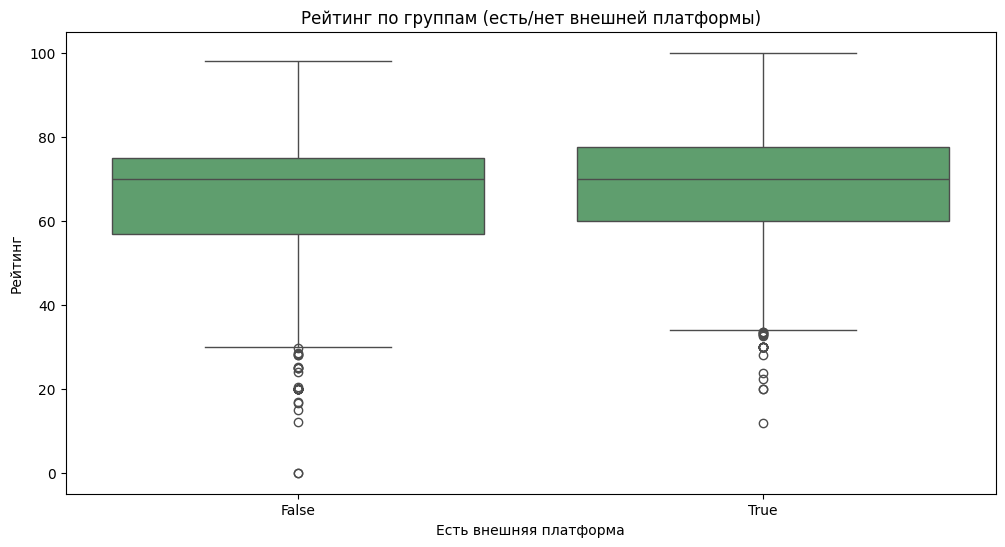

In [103]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='has_external_platform', y='total_rating', color='#55A868')
plt.title('Рейтинг по группам (есть/нет внешней платформы)')
plt.xlabel('Есть внешняя платформа')
plt.ylabel('Рейтинг')

plt.show()


In [104]:
df['high_rating'] = df['total_rating'] >= 70
df.groupby('has_external_platform')['high_rating'].mean() * 100


has_external_platform
False    50.400146
True     59.745500
Name: high_rating, dtype: float64

У игр с внешними источниками рейтинг немного выше, судя по боксплоту, но колоссальных различий нет. Касаемо доли игр, у которых рейтинг более 70, наличие внешних платформ у игры показывает чуть лучшие цифры, чем у их отсутствия. Тем не менее, утверждать что это влияет на рейтинг мы не можем, по причине того, что это скорее слабая корреляция, но не причина. Возможно еще то, что просто успешные игры получают присутствие на внешних площадках

# Ценовое позиционирование

Посмотрим на связь цен в стиме (game_price) с общим рейтингом (total_raiting). Для этого разделим игры на несколько ценовых сегментов и сравним рейтинг внутри этих групп.

Сначала посмотрим, как в целом распределены цены

In [105]:
df["game_price"].describe()

count    6919.000000
mean      343.875958
std       320.137369
min         0.000000
25%       129.000000
50%       259.000000
75%       449.000000
max      6666.000000
Name: game_price, dtype: float64

Проверим сколько бесплатных игр и сколько игр без цены.

In [106]:
print(df["game_price"].isna().sum())
print((df["game_price"] == 0).sum())
print(df["game_price"].shape)

1801
558
(8720,)


### Общее распределение цен

### Цена по жанрам

In [107]:
df_g = df[['genres', 'game_price']].dropna().copy()
df_g['game_price'] = pd.to_numeric(df_g['game_price'])

df_g['genre'] = df_g['genres'].str.split(',')
df_g = df_g.explode('genre') # здесь мы создаем копию строки для каждого элемента списка
df_g['genre'] = df_g['genre'].str.strip()

df_g = df_g[(df_g['genre'] != '')]
df_g = df_g[(df_g['genre'] != 'UNDEFINED')]

genre_price = df_g.groupby('genre')['game_price'].median().reset_index()

genre_price = genre_price.sort_values('game_price', ascending=False)

genre_price

,genre,game_price
18,Tactical,477.5
19,Turn-based strategy (TBS),449.0
10,Quiz/Trivia,392.0
12,Real Time Strategy (RTS),390.0
2,Card & Board Game,360.0
3,Fighting,360.0
15,Simulator,360.0
13,Role-playing (RPG),360.0
17,Strategy,349.0
0,Adventure,320.0


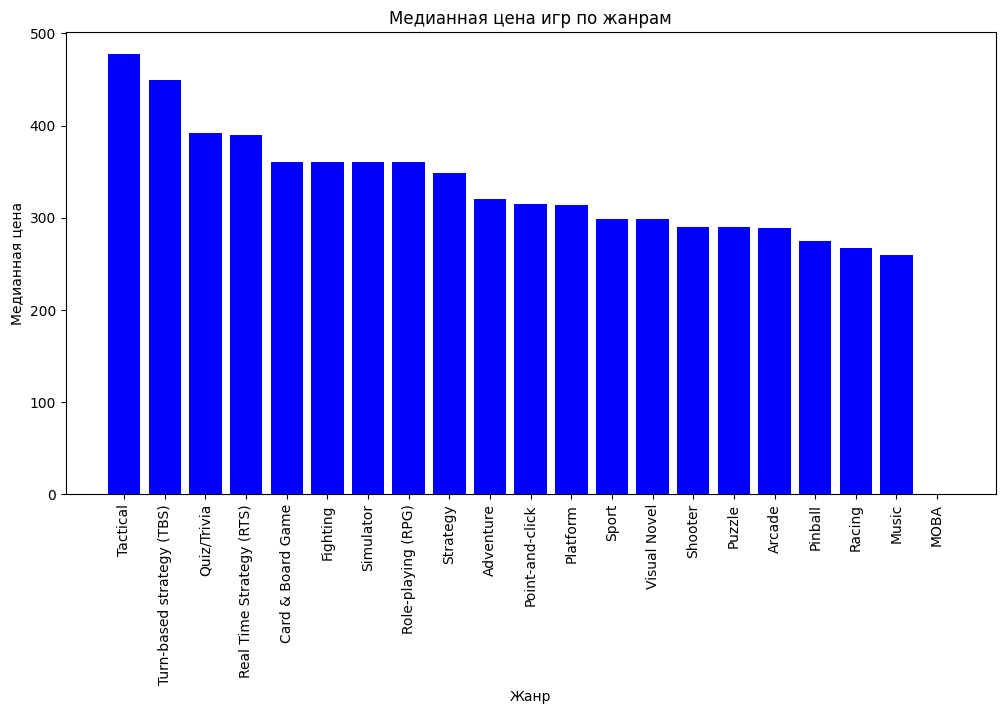

In [108]:

plt.figure(figsize=(12, 6))


plt.bar(genre_price['genre'], genre_price['game_price'], color='blue')

plt.title('Медианная цена игр по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Медианная цена')

plt.xticks(rotation=90)

plt.show()

Самые дорогие игры по медианной цене Tactical и Turn-based strategy, а самые не дорогие Music, Pacing и Pinball

### Связь цены и рейтинга пользователей

Теперь посмотрим еще тщательнее на цену и попробуем определить, есть ли статистически значимая связь между ценой за игру и рейтингом. Для начала нужно посмотреть с какими данными мы имеем дело и определить какой тест нам использовать для определения связи. Сначала, проверим выбросы.

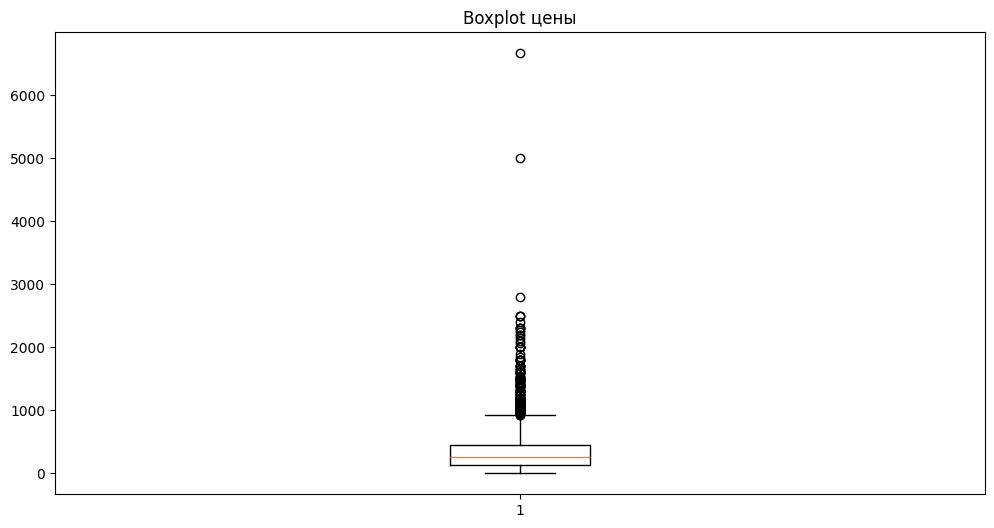

In [109]:
plt.figure(figsize=(12, 6))

plt.boxplot(df['game_price'].dropna())
plt.title('Boxplot цены')

plt.show()

Видим, что выбросов много, Спирмен будет сильно устойчивее к ним, поэтому будем использовать его. Составим гипотезы

H0: rho между рейтингом и ценой за игру 0 (ее нет)

H1: rho между рейтингом и ценой за игру !=0 (связь есть)

In [110]:
from scipy.stats import spearmanr

prob = df[['game_price', 'total_rating']].dropna() #спирмену плохо от пропусков
rho, p_value = spearmanr(prob['game_price'], prob['total_rating'])

rho, p_value

(np.float64(0.26959120001948955), np.float64(1.6408666507720594e-115))

p_value <0.05, что означает что мы отвергаем нулевую и принимаем альтернативную гипотезу о том, что есть статистически значимая связь между ценой на игру и рейтингом. Что касается корреляции, есть небольшая положительная связь, что означает, что в среднем более высокая цена связана с более высоким рейтингом

### Взаимосвязь между жанром, ценовым сегментом, рекомендательные цены

Посчитаем теперь медианные оценки по жанрам, для того чтобы понимать какие цены можно рекомендовать на те или иные игры по жанрам

In [111]:
rat_good = df[df['total_rating'] >= 70].copy()
rat_good['genre'] = rat_good['genres'].str.split(',')
rat_good = rat_good.explode('genre')
rat_good['genre'] = rat_good['genre'].str.strip()

recom = rat_good.groupby('genre')['game_price'].median().sort_values(ascending=False)
recom.head(20)


genre
Quiz/Trivia                  524.000
Tactical                     499.500
Turn-based strategy (TBS)    465.000
Real Time Strategy (RTS)     435.000
Card & Board Game            392.000
Role-playing (RPG)           385.000
Fighting                     385.000
Strategy                     385.000
Simulator                    385.000
Adventure                    360.000
Music                        360.000
Sport                        360.000
Shooter                      349.495
Racing                       349.000
Arcade                       349.000
Puzzle                       349.000
Point-and-click              349.000
Platform                     349.000
Visual Novel                 349.000
Pinball                      274.500
Name: game_price, dtype: float64

Что можно сказать по медианным показателям цен на жанры? Дороже всего Tactical, TBS, RTS - ориентир примерно 435–500 руб. Средний сегмент RPG/Strategy/Simulator - ориентир примерно 385 руб. Жанры Adventure/Puzzle/Shooter/Platform - ориентир примерно 349–360 руб.

Медианные цены по жанрам можно использовать как базовый ориентир для стартового ценообразования новой игры. При этом финальную цену лучше выбирать диапазоном вокруг медианы, надо учитывать качество продукта, конкурентов и многое другое

### Облако слов из названий игр

Источник: https://sergsergius.ru/%D1%81%D0%BE%D0%B7%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5-%D0%BE%D0%B1%D0%BB%D0%B0%D0%BA%D0%B0-%D1%81%D0%BB%D0%BE%D0%B2-%D0%B2-python-%D1%81-%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD/

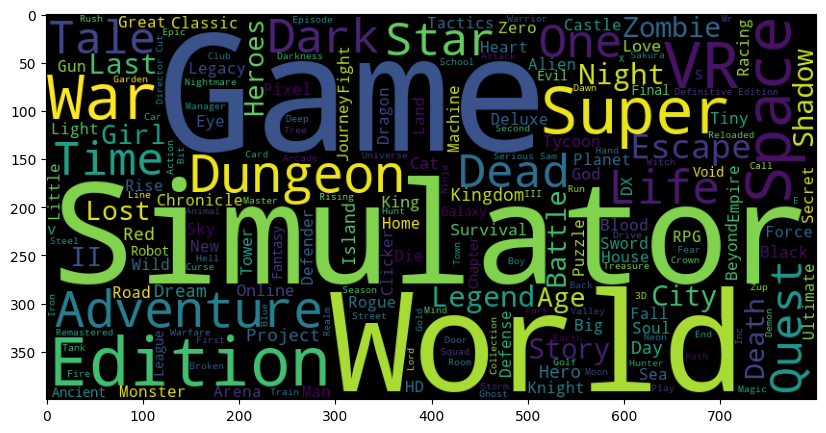

In [112]:
from wordcloud import WordCloud

names = df['game_name']
text = " ".join(names)

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.show()

На основе облака можно выделить четыре тенденции: доминирование ниши симуляторов, практику выпуска Edition, VR, высокую концентрацию проектов в популярных сеттингах Space, Dark, Dungeon, War и Dead и массовое использование базовых терминов Game, World, Super и Adventure в качестве SEO для повышения видимости игр в поиске

# Подведение итогов

## Выводы по результатам анализа

1. Большинство игр оказалось с положительным откликом пользователей
2. Распределения по отзывам и числу оценок имеют длинный хвост (много малых значений и немного очень больших)
3. Русскоязычный отзывы есть только у части игр, при этом как было выявлено в рамках анализа - все эти игры имеют неотрицательные отзывы по миру -  has_russian_reviews=1 у 1414 игр из 8720
5. Бесплатные игры имеют более высокую медиану отзывов: 1407 против 374

## Рекомендации

По итогам исследования можем дать заказчикам следующие рекомендации:


1. Игры в жанре Adventure очень много и будет большая конкруренция - если хочется создать успешный продукт, то эффективнее будет рассмотреть жанры Tactical и TBS - они менее популярны и при этом в среднем выше по рейтингу чем остальные жанры.

2. С точки зрения ценевой политики советуем ориентироваться заказчику на следующий ценовой диапазон 435-500 руб, так как именно тут находятся медианные цены успешных игр этих жанров. Его можно использовать для старта, а финальную цену корректировать с учетом конкурентов, качества продукта, объема контента.

По итогу, для получения лучших результатов стоит планировать следующую игру жанр - Tactical и TBS, цена 435-500 руб. Для публикации целесообразно также работать с внешними платформами, у таких игр выше метрики вовлеченности